In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import sympy as sp

In [37]:
# upr 1

def generate_dots(f, x0, y0, a, b, n):
    dx = (b - a) / n
    x_i = [x0 + dx * i for i in range(n + 1)]
    y_i = [y0]
    for i in range(1, len(x_i)):
        y_i.append(y_i[-1] + f.subs({x: x_i[i - 1], y: y_i[-1]}) * dx)
    
    return (x_i, y_i)

def dots_error(dots1, dots2):
    dy = []
    for i in range(len(dots1)):
        for k in range(len(dots2)):
            if (dots1[i][0] == dots2[k][0]):
                dy.append(abs(dots1[i][1] - dots2[k][1]))
    
    return max(dy)
    

def diff_euler(f, x0, y0, a, b, n0, eps):
    dots1 = generate_dots(f, x0, y0, a, b, n0)
    dots2 = generate_dots(f, x0, y0, a, b, 2 * n0)
    
    dots3 = dots1[::]
    dots4 = dots2[::]
    n = 2 * n0
    while (dots_error(dots3, dots4) >= eps):
        n = n * 2
        dots3 = dots4
        dots4 = generate_dots(f, x0, y0, a, b, n)
        
    plt.plot(dots1[0], dots1[1], label=f'n0 = {n0}')
    plt.plot(dots2[0], dots2[1], label=f'2 * n0 = {2 * n0}')
    plt.plot(dots4[0], dots4[1], label=f'n = {n}')
    plt.legend()
    
    return dots4, n
    

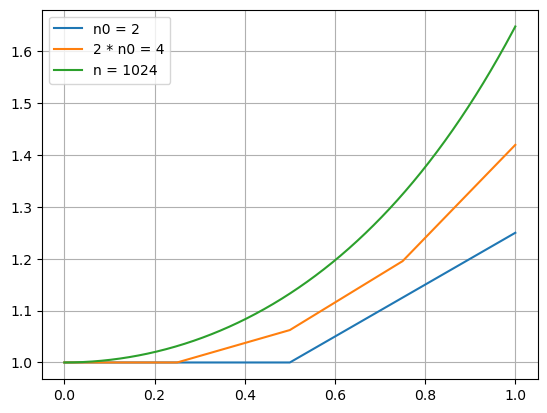

In [38]:
x = sp.Symbol('x')
y = sp.Symbol('y')

iter_solution, n = diff_euler(x * y, 0, 1, 0, 1, 2, 0.001)
plt.grid()

точное решение  

$$ \frac{dy}{dx} = xy $$  
$$ \frac{dy}{y} = xdx $$  
$$ \int \frac{dy}{y} = \int xdx $$  
$$ \ln|y| = \frac{x^2}{2} + \ln|C| $$  
$$ \ln{|\frac{y}{C}|} = \frac{x^2}{2} = \ln{e^{\frac{x^2}{2}}} $$  
$$ \frac{y}{C} = e^{\frac{x^2}{2}} $$  
$$ y = C e^{\frac{x^2}{2}} $$  
при y(0) = 1  
$$ y = e^{\frac{x^2}{2}} $$

In [39]:
def sol(x):
    return np.exp(x**2 / 2)

difference = []
for i in range(len(iter_solution[0])):
    difference.append(abs(sol(iter_solution[0][i]) - iter_solution[1][i]))

print('оценка реальной точности приближения:', max(difference))

оценка реальной точности приближения: 0.00107251359680705


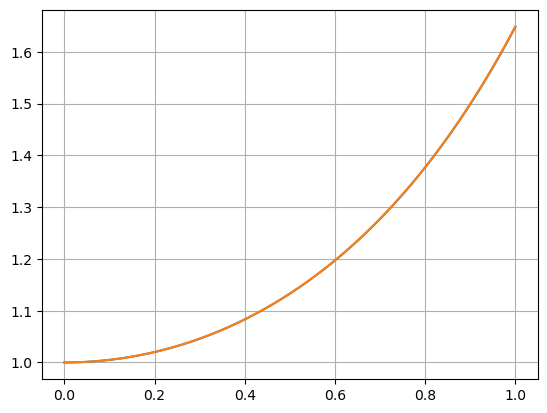

In [42]:
plt.plot(iter_solution[0], iter_solution[1])
x1 = np.linspace(0, 1, 1000)
plt.plot(x1, sol(x1))
plt.grid()

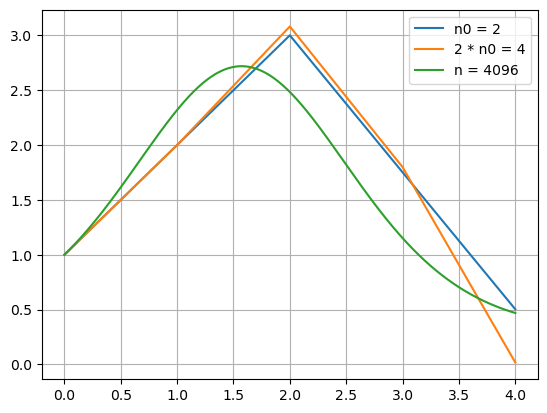

In [44]:
# y' = cos(x) * y
# y(0) = 1
# x \in [0; 4]
# eps = 0.001

x = sp.Symbol('x')
y = sp.Symbol('y')

iter_solution, n = diff_euler(sp.cos(x) * y, 0, 1, 0, 4, 2, 0.001)
plt.grid()

аналитическое решение  

$$ y' = \cos{x} y $$  
$$ \frac{dy}{dx} = \cos{x} y $$  
$$ \frac{dy}{y} = \cos{x} dx $$  
$$ \ln{\frac{y}{C}} = \sin{x} $$  
$$ y = C e^{\sin{x}} $$  
при $ y(0) = 1 $  
$$ y = e^{\sin{x}} $$

In [45]:
def sol(x):
    return np.exp(np.sin(x))

difference = []
for i in range(len(iter_solution[0])):
    difference.append(abs(sol(iter_solution[0][i]) - iter_solution[1][i]))

print('оценка реальной точности приближения:', max(difference))

оценка реальной точности приближения: 0.000796488852166544


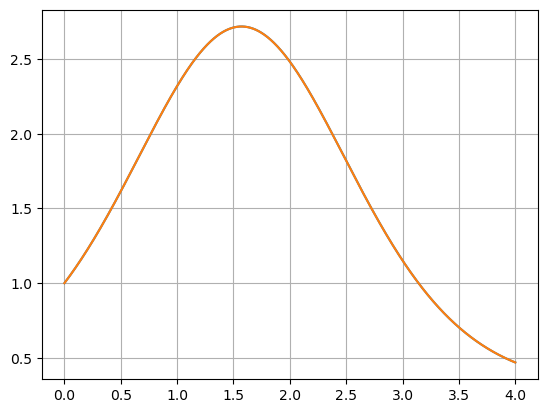

In [47]:
plt.plot(iter_solution[0], iter_solution[1])
x1 = np.linspace(0, 4, 1000)
plt.plot(x1, sol(x1))
plt.grid()

In [127]:
# upr 2


def pikar(f, x, y, x0, y0, a, b, n0):
    t = sp.Symbol('t')
    phi = [y0]
    for i in range(1, n0):
        phi_i = y0 + sp.integrate(f.subs({x: t, y: phi[-1]}), (t, x0, x))
        phi.append(phi_i)
    
    x1 = np.linspace(a, b)
    plt.axhline(y0, label='n = 0')
    j = 1
    for i in phi[1::]:
        y1 = [i.subs(x, k) for k in x1]
        plt.plot(x1, y1, label=f'n = {j}')
        j += 1
    
    return phi

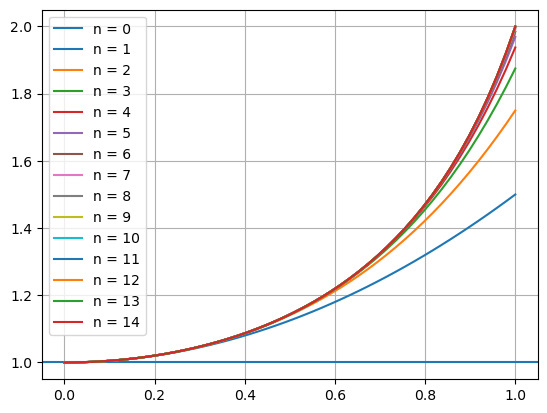

In [128]:
x = sp.Symbol('x')
y = sp.Symbol('y')

iter_s = pikar(x * y, x, y, 0, 1, 0, 1, 15)
plt.grid()
plt.legend()

In [129]:
def sol(x):
    return np.exp(x**2 / 2)

x1 = np.linspace(0, 1)
y1 = [iter_s[-1].subs(x, i) for i in x1]
y1_prec = sol(x1)
diff = [abs(i - k) for i, k in zip(y1, y1_prec)]

print('оценка реальной точности приближения для 5 итераций:', max(diff))

оценка реальной точности приближения для 5 итераций: 0.351217694143622


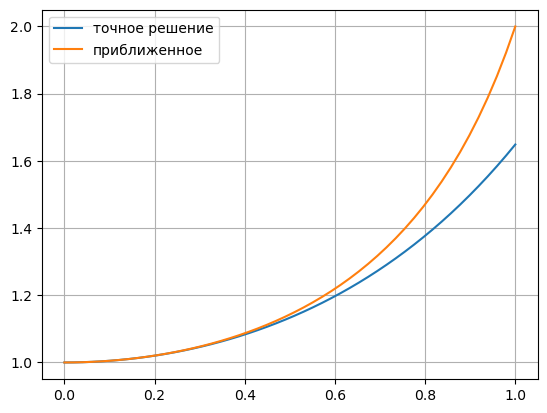

In [130]:
plt.plot(x1, y1_prec, label='точное решение')
plt.plot(x1, y1, label='приближенное')
plt.legend()
plt.grid()

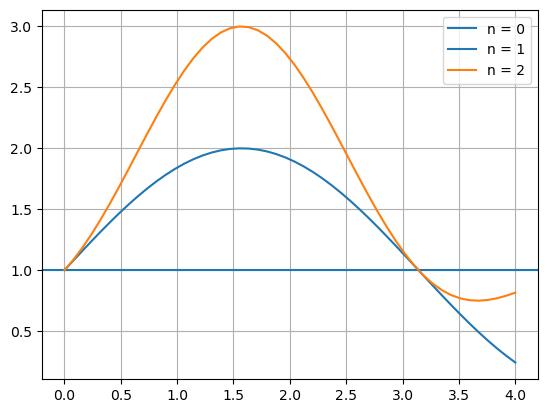

In [131]:
# y' = cos(x) * y
# y(0) = 1
# x \in [0; 4]


x = sp.Symbol('x')
y = sp.Symbol('y')

iter_s = pikar(sp.cos(x) * y, x, y, 0, 1, 0, 4, 3)
plt.grid()
plt.legend()

In [132]:
def sol(x):
    return np.exp(np.sin(x))

x1 = np.linspace(0, 4)
y1 = [iter_s[-1].subs(x, i) for i in x1]
y1_prec = sol(x1)
diff = [abs(i - k) for i, k in zip(y1, y1_prec)]

print('оценка реальной точности приближения для 3 итераций:', max(diff))

оценка реальной точности приближения для 3 итераций: 0.346783335722378


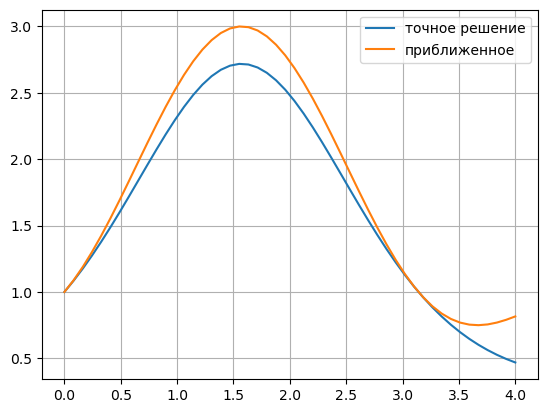

In [133]:
plt.plot(x1, y1_prec, label='точное решение')
plt.plot(x1, y1, label='приближенное')
plt.legend()
plt.grid()